# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import random
import pandas as pd 
import numpy as np

import time 
from tqdm import tqdm
from typing import Iterable
from datetime import datetime

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS

from scipy.integrate import quad 

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['text.usetex'] = False

In [5]:
from core.variables import * 
from core.estimators import *

# DGP

In [6]:
class DGP1:
    """ 
    Data Generating Process 1:
    \tau_i \in \{a_1, \dots, a_K\}  # K groups, each with a different treatment effect a_k 
    Y_i = \tau_i T_i + \epsilon_i, \epsilon_i \sim N(0, \sigma^2)  # outcome model
    T_i \sim Bernoulli(p)  # treatment assignment model
    """
    def __init__(
        self, te_list: list, group_func: callable, 
        noise_std: float = 1.0, treatment_assign_prob: float = 0.5, **kwargs
    ):
        """  
        DGP for model 1

        Params:
        -------
        te_list: list, list of treatment effects for each group
        group_func: callable, function that assigns each observation to a group
        noise_std: float, standard deviation of the noise in the outcome model
        treatment_assign_prob: float, probability of treatment assignment
        """
        # attributes
        self.te_list = te_list
        self.group_func = group_func
        self.noise_std = noise_std
        self.treatment_assign_prob = treatment_assign_prob

    def generate_training_data(self, sample_size: int, seed=None) -> tuple:
        """
        Generate training data

        Params:
        -------
        sample_size: int, number of samples to generate

        Returns:
        -------
        tuple: 
            - X: np.ndarray, covariate
            - T: np.ndarray, treatment assignment
            - Y: np.ndarray, outcome
        """
        # set seed
        seed = seed if seed else np.random.randint(0, 1e6)
        np.random.seed(seed)

        # treatment effect function: given a covariate x, return the treatment effect of the group
        te_func = lambda x: self.te_list[self.group_func(x)]
        
        # generate data
        X = self.__generate_individual_characteristics(sample_size, seed)  # (sample_size, )
        T = np.random.binomial(1, 0.5, sample_size)  # (sample_size, )
        te_arr = np.array([te_func(x) for x in X])  # (sample_size, )
        Y = te_arr * T  + np.random.normal(0, self.noise_std, sample_size)  # (sample_size, )
        
        return X.reshape(-1, 1), T.reshape(-1, 1), Y.reshape(-1, 1)  # (sample_size, 1)
    
    def generate_testing_data(self, sample_size: int, seed=None) -> np.ndarray:
        seed = seed if seed else np.random.randint(0, 1e6)
        
        # generate data
        X = self.__generate_individual_characteristics(sample_size, seed) # (sample_size, )

        return X  # (sample_size, )

    def __generate_individual_characteristics(self, sample_size: int, seed: int) -> np.ndarray:
        np.random.seed(seed)
        return np.random.uniform(-3, 3, sample_size)

In [7]:
def get_best_targeting_val(X: np.ndarray, dgp: DGP1, budget: int = 1) -> float:
    true_est = np.zeros(X.shape)
    true_group = np.array([dgp.group_func(x) for x in X])
    
    for i in range(len(dgp.te_list)):
        true_est[true_group == i] = dgp.te_list[i]

    true_val = -np.sort(-true_est)[:budget].sum()

    return true_val

def evaluate_targeting_policy(X: np.ndarray, targeting_arr: np.ndarray, dgp: DGP1, budget: int = 1) -> float:
    """  
    Calculate the actual targeting value of a given targeting decision

    params:
    -------
    X: np.ndarray, shape (n_samples, d), the covariates
    targeting_arr: np.ndarray, shape (n_samples, ), the targeting decision
    dgp: DGP1, the data generating process
    budget: int, the number of customers to target
    """
    assert X.shape[0] == targeting_arr.shape[0], 'X and targeting_arr must have the same number of samples'
    assert targeting_arr.sum() <= budget, 'The sum of the targeting array must be within the budget'

    true_est = np.zeros(X.shape)
    true_group = np.array([dgp.group_func(x) for x in X])

    for i in range(len(dgp.te_list)):
        true_est[true_group == i] = dgp.te_list[i]

    true_val = true_est[targeting_arr == 1].sum()

    return true_val

# Experiments

In [8]:
class BinaryCorrection(object):
    def __init__(self, group_func: callable, n_groups: int):
        self.group_func = group_func 
        self.n_groups = n_groups
        self.plugin_estimator = BinaryPlugIn(group_func=group_func, n_groups=n_groups)

        # place holders
        self.n_bootstrap = None  # number of bootstrap samples
        self.boot_est_arr = None  # (n_bootstrap, n_groups)
        self.boot_se_arr = None  # (n_bootstrap, n_groups)

    def fit(self, X: np.ndarray, T: np.ndarray, Y: np.ndarray, n_bootstrap: int = 100):
        # fill in placeholders
        self.n_bootstrap = n_bootstrap
        self.boot_est_arr = np.zeros(shape=(self.n_bootstrap, self.n_groups))  # (n_bootstrap, n_groups)
        self.boot_se_arr = np.zeros(shape=(self.n_bootstrap, self.n_groups))  # (n_bootstrap, n_groups)

        # assign each customer to a group
        group_arr = np.array([self.group_func(x) for x in X])  # (n_obs, )

        for b in range(self.n_bootstrap):
            for i in range(self.n_groups):
                # sample with replacement from each group
                group_idx = np.where(group_arr == i)[0]
                boot_idx = np.random.choice(group_idx, size=group_idx.shape[0], replace=True)

                # fit OLS
                ols = OLS(Y[boot_idx], T[boot_idx]).fit()
                self.boot_est_arr[b, i] = ols.params[0]
                self.boot_se_arr[b, i] = ols.bse[0]

        self.plugin_estimator.fit(X, T, Y)

        return self
    
    def estimate_targeting_value(self, X: np.ndarray, budget: int = 1) -> np.ndarray:
        """   
        Given a set of covariates, estimate the treatment effect for each covariate.

        Params:
        -------
        X: np.ndarray, shape (n_oobs, 1), the covariates
        budget: int, the number of customers to target

        Returns:
        -------
        np.ndarray, shape (n_bootstraps, n_oobs)
        """
        # assign each customer to a group
        group_arr = np.array([self.group_func(x) for x in X])  # (n_obs, )

        # create an array to store the treatment effect estimates for each bootstrap sample
        boot_est_arr = self.boot_est_arr[:, group_arr]  # (n_bootstraps, n_obs)
        boot_se_arr = self.boot_se_arr[:, group_arr]  # (n_bootstraps, n_obs)

        # calculate empirical estimation error
        xi_arr = boot_est_arr - boot_est_arr.mean(axis=0)  # (n_bootstraps, n_obs)

        # create a mask to identify the treated individuals within each bootstrap sample
        # if the treatment effect estimate is among the largests, the mask is 1, otherwise 0
        # if ties, select the ones with smaller indexes
        mask_arr = np.zeros_like(xi_arr)
        # sort the treatment effect estimates in descending order for each bootstrap sample
        sorted_columns = np.argsort(-boot_est_arr, axis=1)[:, :budget]

        # set the mask to 1 for the treated individuals
        rows = np.repeat(np.arange(boot_est_arr.shape[0])[:, None], budget, axis=1)
        mask_arr[rows, sorted_columns] = 1

        del sorted_columns, rows

        # calculate the correction term
        correction = np.mean(np.sum(mask_arr * xi_arr, axis=1))

        # calculate plugin estimate
        plugin_estimate = self.plugin_estimator.estimate_targeting_value(X, budget=budget)

        # calculate the corrected treatment effect estimate
        return plugin_estimate - correction

In [9]:
# parameters
train_size = 100
test_size = 10
te_list = [1, 1.1]
group_func = lambda x: 0 if x < 0 else 1

# initialize the data generating process
num_groups = len(te_list)
dgp = DGP1(te_list, group_func)

train_x, train_t, train_y = dgp.generate_training_data(train_size)
test_x = dgp.generate_testing_data(test_size)

# train estimators 
plugin_estimator = BinaryPlugIn(dgp.group_func, num_groups).fit(train_x, train_t, train_y)  # plugin estimator
corr_estimator = BinaryCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstrap=5000)  # bootstrap correction estimator
adj_corr_estimator = BinaryAdjustedCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstrap=5000)  # adjusted bootstrap correction estimator

In [10]:
# evalute test set 
budget = 1

best_targ_val = get_best_targeting_val(test_x, dgp, budget=budget)
plugin_targ_est = plugin_estimator.estimate_targeting_value(test_x, budget=budget)
true_plugin_targ_val = evaluate_targeting_policy(test_x, plugin_estimator.get_targeting_decision(test_x, budget), dgp, budget=budget)
correction_target_est = corr_estimator.estimate_targeting_value(test_x, budget=budget)
adj_corr_target_est = adj_corr_estimator.estimate_targeting_value(test_x, budget=budget)

print(f"Best targeting value: {best_targ_val:.4f}\n")

print(f"Plugin targeting estimate: {plugin_targ_est:.4f}")
print(f"Correction targeting estimate: {correction_target_est:.4f}")
print(f"Adjusted correction targeting estimate: {adj_corr_target_est:.4f}")

print(f"\nActual value of plugin targeting: {true_plugin_targ_val:.4f}")
print(f"Winner's Curse of plugin estimate: {plugin_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of correction estimat: {correction_target_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of adjusted correction estimate: {adj_corr_target_est - true_plugin_targ_val:.4f}")

Best targeting value: 1.1000

Plugin targeting estimate: 1.2160
Correction targeting estimate: 1.1114
Adjusted correction targeting estimate: 1.1381

Actual value of plugin targeting: 1.0000
Winner's Curse of plugin estimate: 0.2160
Winner's Curse of correction estimat: 0.1114
Winner's Curse of adjusted correction estimate: 0.1381


In [11]:
def single_experiment(
    dgp_params: dict, 
    targeting_params: dict, 
    estimators_dict: dict, 
    save_estimator: bool = False, 
    seed=None
) -> dict:
    """  
    Run a single experiment

    Params:
    -------
    dgp_params: dict, parameters for the data generating process
    targeting_params: dict, parameters for the targeting policy
    estimators_dict: dict, dictionary containing the estimators and their parameters
    save_estimator: bool, whether to save the estimator
    seed: int, random seed
    
    Returns:
    --------
    dict: Dictionary containing the following keys:
        - best_targ_val: float, the best targeting value
        - plugin_targ_est: float, the plugin targeting estimate
        - true_plugin_targ_val: float, the actual value of the plugin targeting decision
        - param_targ_est: float, the parametric targeting estimate
        - bayes_param_targ_est: float, the bayesian parametric targeting estimate
        - boot_correction_target_est: float, the bootstrap correction targeting estimate
    """
    # set seed
    seed = seed if seed is not None else np.random.randint(0, 1e6)

    # initialize result dictionary
    result_dict = {name: None for name in estimators_dict.keys()}

    # initialize the data generating process
    dgp = DGP1(**dgp_params)

    train_x, train_t, train_y = dgp.generate_training_data(dgp_params['train_size'], seed=seed)  # generate training data
    test_data = dgp.generate_testing_data(targeting_params['size'], seed=seed)  # generate targeting individuals

    # define and train estimators
    for estimator_name, estimator_dict in estimators_dict.items():
        estimator = estimator_dict['estimator'](
            group_func=dgp.group_func, n_groups=len(dgp_params['te_list'])
        ).fit(X=train_x, T=train_t, Y=train_y, **estimator_dict['train_params'])
        targ_est = estimator.estimate_targeting_value(
            X=test_data, budget=targeting_params['budget'], 
            **estimator_dict['targeting_params']
        )
        if save_estimator:
            result_dict[estimator_name] = {
                'estimator': estimator, 'targ_est': targ_est
            }
        else:
            result_dict[estimator_name] = {'targ_est': targ_est}

        if estimator_name == 'plugin':
            result_dict[estimator_name]['act_targ_val'] = evaluate_targeting_policy(
                X=test_data, targeting_arr=estimator.get_targeting_decision(test_data, targeting_params['budget']), 
                dgp=dgp, budget=targeting_params['budget']
            )

    result_dict['clairvoyant'] = get_best_targeting_val(test_data, dgp, budget=targeting_params['budget'])

    return result_dict


In [20]:
def grid_experiment(
    sample_sizes: Iterable[int], 
    num_bootstraps: Iterable[int],
    noise_stds: Iterable[float],
    dgp_params: dict,
    targeting_params: dict,
    estimators_dict: dict,
    save_dir: str, 
    num_repeats: int,
    verbose: bool = False
) -> list:
    """  
    Run a grid of experiments

    Params:
    -------
    sample_sizes: Iterable[int], the sample sizes to consider
    num_bootstraps: Iterable[int], the number of bootstrap samples to consider
    noise_stds: Iterable[float], the standard deviations of the noise to consider
    dgp_params: dict, parameters for the data generating process
    targeting_params: dict, parameters for the targeting policy
    estimators_dict: dict, dictionary containing the estimators and their parameters
    save_dir: str, the directory to save the results
    num_repeats: int, the number of times to repeat the experiment
    verbose: bool, whether to print progress
    
    Returns:
    --------
    list: List of dictionaries containing the results of the experiments
    """
    results = []

    # create an array to store the grid of experiment parameters
    knob_dict = {
        'sample_size': sample_sizes, 'num_bootstrap': num_bootstraps, 'noise_std': noise_stds
    }
    knob_val_grids = np.array([
        [sample_size, num_bootstrap, noise_std]  # * Must be in the same order as knob_keys
        for sample_size in sample_sizes
        for num_bootstrap in num_bootstraps
        for noise_std in noise_stds
    ])

    # check if any of the knobs have a single value
    fixed_knob_keys = [
        knob_key for knob_key, knob_val_list in knob_dict.items() if len(knob_val_list) == 1
    ]

    # print knob keys and values for the ones that have a single value
    if len(fixed_knob_keys) > 0:
        for knob_key in fixed_knob_keys:
            print(f"{knob_key}={knob_dict[knob_key][0]}")

    for sample_size, num_bootstrap, noise_std in knob_val_grids:
        start = datetime.now()
        for seed in range(num_repeats):
            dgp_params['train_size'] = int(sample_size)
            dgp_params['noise_std'] = noise_std

            # change n_bootstrap parameters for the correction estimators
            for estimator_name in estimators_dict.keys():
                if 'n_bootstrap' in estimators_dict[estimator_name]['train_params'].keys():
                    estimators_dict[estimator_name]['train_params']['n_bootstrap'] = int(num_bootstrap)

            result_dict = single_experiment(
                dgp_params=dgp_params, 
                targeting_params=targeting_params, 
                estimators_dict=estimators_dict, 
                save_estimator=False, 
                seed=seed
            )

            for knob_key, knob_val in knob_dict.items():
                result_dict[knob_key] = knob_val
            results.append(result_dict)

        if verbose:
            # print parameter values except for the fixed ones
            for knob_key, knob_val in knob_dict.items():
                if knob_key not in fixed_knob_keys:
                    print(f"{knob_key}={knob_val}, "), 
            print(f"Time taken: {datetime.now() - start}")

    # organize results into a dataframe
    result_df = pd.DataFrame.from_records([
        {
            **{knob_key: result_dict[knob_key] for knob_key in knob_dict.keys()},
            **{
                f"{estimator_name}_est": result_dict[estimator_name]['targ_est'] 
                for estimator_name in estimators_dict.keys()
            }, 
            'act_plugin_val': result_dict['plugin']['act_targ_val'], 
        }
        for result_dict in results
    ])

    result_df.to_csv(save_dir, index=False)

    return result_df

In [97]:
def plot_winners_curse_hist(result_dir: str, estimators: list, **kwargs):
    # read data
    result_df = pd.read_csv(result_dir)

    # fixed knobs keys 
    target_columns = [f'{estimator}_est' for estimator in estimators] + ['act_plugin_val']
    fixed_knob_keys = [col for col in result_df.columns if col not in target_columns]
    fixed_knob_vals = [result_df[key].iloc[0] if key not in kwargs.keys() else kwargs[key] for key in fixed_knob_keys]

    # extract the data for the fixed knobs
    fixed_knob_mask_list = np.array([
        (result_df[key] == val).values for key, val in zip(fixed_knob_keys, fixed_knob_vals)
    ])
    result_df = result_df[pd.Series(np.all(fixed_knob_mask_list, axis=0), index=result_df.index)]

    # calculate winner's curse
    for estimator in estimators:
        result_df[f'{estimator}_wc'] = result_df[f"{estimator}_est"] - result_df['act_plugin_val']

    # clean unnecessary columns
    result_df = result_df[[f'{estimator}_wc' for estimator in estimators]]


    fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

    for i, col in enumerate(result_df.columns):
        axes[0].hist(result_df[col], bins=20, alpha=0.6, color=f'C{i}', label=col, density=True)
        axes[0].axvline(result_df[col].mean(), linestyle='--', linewidth=2.5, color=f'C{i}', label=f'{col} Mean')

    axes[0].set_xlabel('Winner\'s Curse')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Winner\'s Curse of Different Estimators')
    axes[0].legend()

    for i, col in enumerate(result_df.columns):
        axes[1].violinplot(result_df[col], positions=[i], showmeans=True, showextrema=False)
        
    axes[1].set_xticks(range(len(result_df.columns)))
    axes[1].set_xticklabels(result_df.columns)
    axes[1].set_xlabel('Estimator')
    axes[1].set_ylabel('Winner\'s Curse')
    axes[1].set_title('Winner\'s Curse of Different Estimators')

    for ax in axes:
        ax.grid()

    plt.show()

def plot_winners_curse_2d(result_dir: str, estimators: list, x: str, **kwargs):
    # read data
    result_df = pd.read_csv(result_dir)

    # check if x and y are columns in the dataframe
    assert x in result_df.columns, f'{x} is not a column in the dataframe'

    # fixed knobs keys 
    target_columns = [x] + [f'{estimator}_est' for estimator in estimators] + ['act_plugin_val']
    fixed_knob_keys = [col for col in result_df.columns if col not in target_columns]
    fixed_knob_vals = [result_df[key].iloc[0] if key not in kwargs.keys() else kwargs[key] for key in fixed_knob_keys]

    # extract the data for the fixed knobs
    fixed_knob_mask_list = np.array([
        (result_df[key] == val).values for key, val in zip(fixed_knob_keys, fixed_knob_vals)
    ])
    result_df = result_df[pd.Series(np.all(fixed_knob_mask_list, axis=0), index=result_df.index)]

    # calculate winner's curse
    for estimator in estimators:
        result_df[f'{estimator}_wc'] = result_df[f"{estimator}_est"] - result_df['act_plugin_val']

    # clean unnecessary columns
    result_df = result_df[[x] + [f'{estimator}_wc' for estimator in estimators]]

    # calcualte the average and standard deviation of the winner's curse across repeated trials
    avg_result_df = result_df.groupby([x]).mean().reset_index()

    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    for i, estimator_name in enumerate([f'{estimator}_wc' for estimator in estimators]):
        ax.plot(avg_result_df[x], avg_result_df[estimator_name], 'o-', label=estimator_name, color=f'C{i}')

    ax.set_xlabel(x.replace('_', ' ').capitalize())
    ax.set_ylabel('Winner\'s Curse')
    ax.set_title(f'Winner\'s Curse of Different Estimators')
    ax.grid()
    ax.legend()

    plt.show()

def plot_winners_curse_3d(result_dir: str, estimators: list, x: str, y: str, **kwargs): 
    # read data
    result_df = pd.read_csv(result_dir)

    # check if x and y are columns in the dataframe
    assert x in result_df.columns, f'{x} is not a column in the dataframe'
    assert y in result_df.columns, f'{y} is not a column in the dataframe'

    # fixed knobs keys 
    target_columns = [x, y] + [f'{estimator}_est' for estimator in estimators] + ['act_plugin_val']
    fixed_knob_keys = [col for col in result_df.columns if col not in target_columns]
    fixed_knob_vals = [result_df[key].iloc[0] if key not in kwargs.keys() else kwargs[key] for key in fixed_knob_keys]

    # extract the data for the fixed knobs
    fixed_knob_mask_list = np.array([
        (result_df[key] == val).values for key, val in zip(fixed_knob_keys, fixed_knob_vals)
    ])
    result_df = result_df[pd.Series(np.all(fixed_knob_mask_list, axis=0), index=result_df.index)]

    # calculate winner's curse
    for estimator in estimators:
        result_df[f'{estimator}_wc'] = result_df[f"{estimator}_est"] - result_df['act_plugin_val']

    # clean unnecessary columns
    result_df = result_df[[x, y] + [f'{estimator}_wc' for estimator in estimators]]

    # calcualte the average and standard deviation of the winner's curse across repeated trials
    avg_result_df = result_df.groupby([x, y]).mean().reset_index()

    # visualization params
    vmin = -0.05
    vmax = 1.1 * round(np.max(avg_result_df[[f'{estimator}_wc' for estimator in estimators]].max()), 4)

    # make a 3D plot, sample size vs num bootstrap vs winner's curse
    fig, axes = plt.subplots(1, len(estimators), figsize=(5 * len(estimators), 6.18), subplot_kw={'projection': '3d'})

    for estimator, ax in zip([f'{estimator}_wc' for estimator in estimators], axes):
        surf = ax.plot_trisurf(
            avg_result_df[x], avg_result_df[y], avg_result_df[estimator], 
            cmap=cm.jet, alpha=0.6, label=estimator.replace('_', ' ').capitalize(), vmin=vmin, vmax=vmax
        )
        ax.set_title(f"Winner\'s Curse of {estimator.replace('_', ' ').capitalize()}")
        ax.set_xlabel(x.replace('_', ' ').capitalize())
        ax.set_ylabel(y.replace('_', ' ').capitalize())
        ax.set_zlabel('Winner\'s Curse')
        ax.set_zlim(vmin, vmax)

    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
    fig.colorbar(surf, cax=cbar_ax)

    plt.show()

## Test 1

In [14]:
# parameters
dgp_params = {
    'te_list': [1.0, 1.1],  # treatment effects for each group
    'group_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': 100,  # size of training set
    'noise_std': 1.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # adjusted bootstrap correction estimator, 
}

In [16]:
grid_results = grid_experiment(
    sample_sizes=[100, 200, 300, 400, 500, 1000, 1500, 2000, 3000, 4000, 5000], 
    num_bootstraps=[500],
    noise_stds=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/wc_grid11.csv',
    num_repeats=50, verbose=True
)

Sample size=100.0, Num bootstrap=500.0, Noise STD=0.5, Time taken: 0:00:09.593451 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=1.0, Time taken: 0:00:09.659068 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=1.5, Time taken: 0:00:09.661456 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=2.0, Time taken: 0:00:09.657620 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=2.5, Time taken: 0:00:09.611867 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=3.0, Time taken: 0:00:09.605324 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=4.0, Time taken: 0:00:09.567225 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=5.0, Time taken: 0:00:09.614800 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=6.0, Time taken: 0:00:09.698537 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=7.0, Time taken: 0:00:09.707866 seconds
Sample size=100.0, Num bootstrap=500.0, Noise STD=8.0, Time taken: 0:00:09.691570 seconds
Sample siz

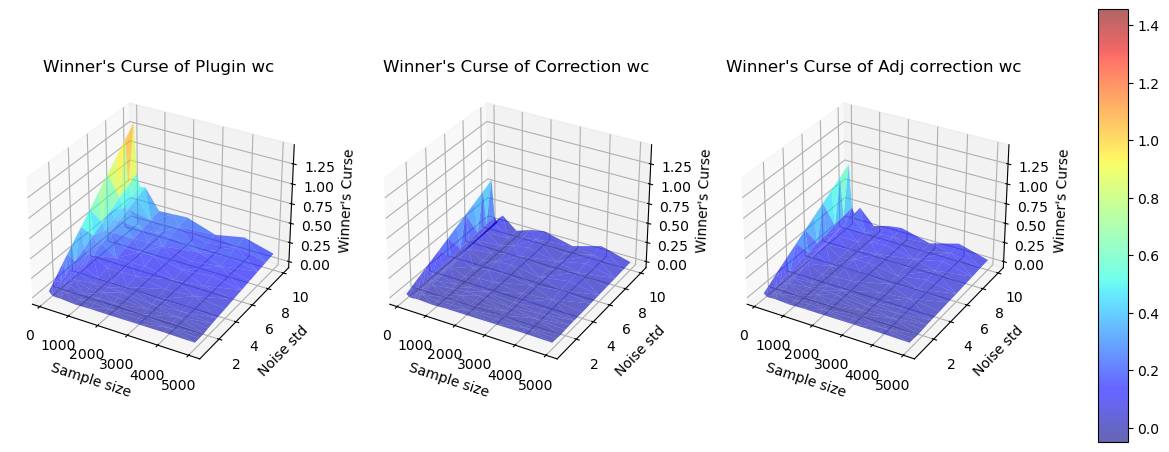

In [84]:
plot_winners_curse_3d(
    'results/wc_grid11.csv', estimators=list(estimators_dict.keys()), x='sample_size', y='noise_std', 
    num_bootstrap=500
)

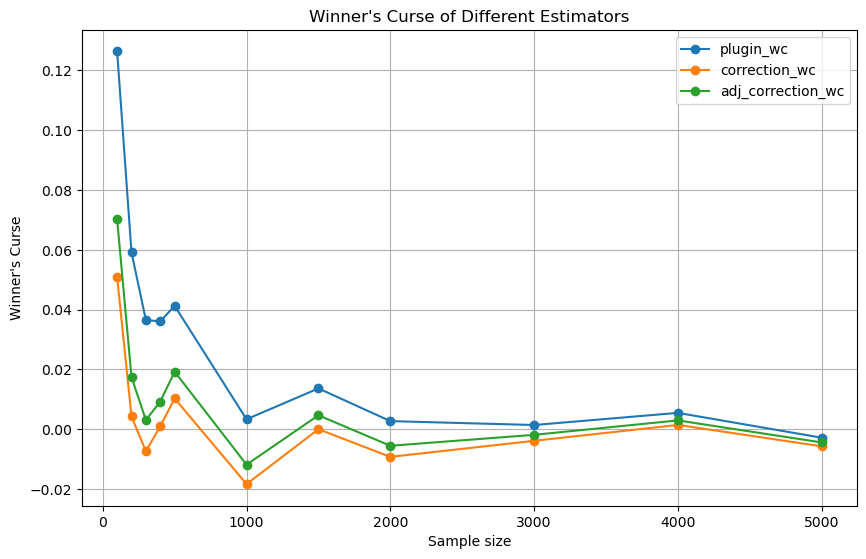

In [96]:
plot_winners_curse_2d(
    'results/wc_grid11.csv', x='sample_size', noise_std=1.0,
    estimators=list(estimators_dict.keys())
)

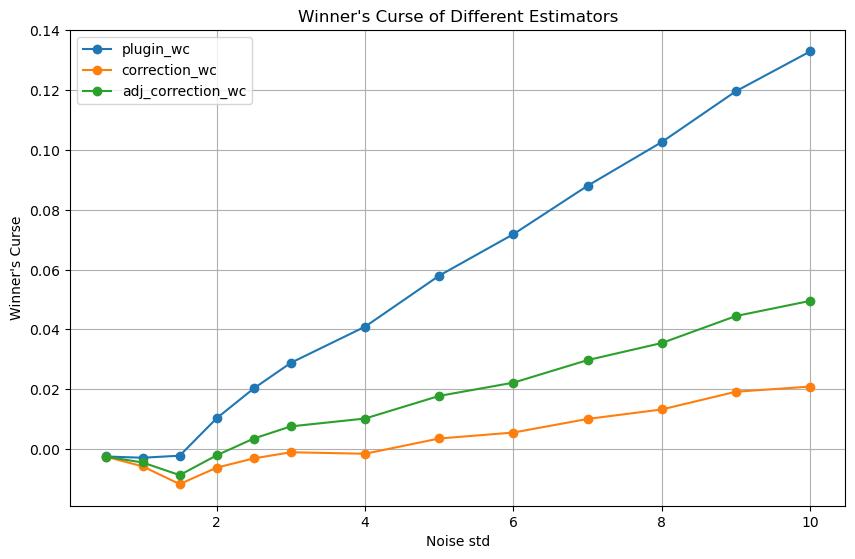

In [121]:
plot_winners_curse_2d(
    'results/wc_grid11.csv', x='noise_std', sample_size=5000,
    estimators=list(estimators_dict.keys())
)

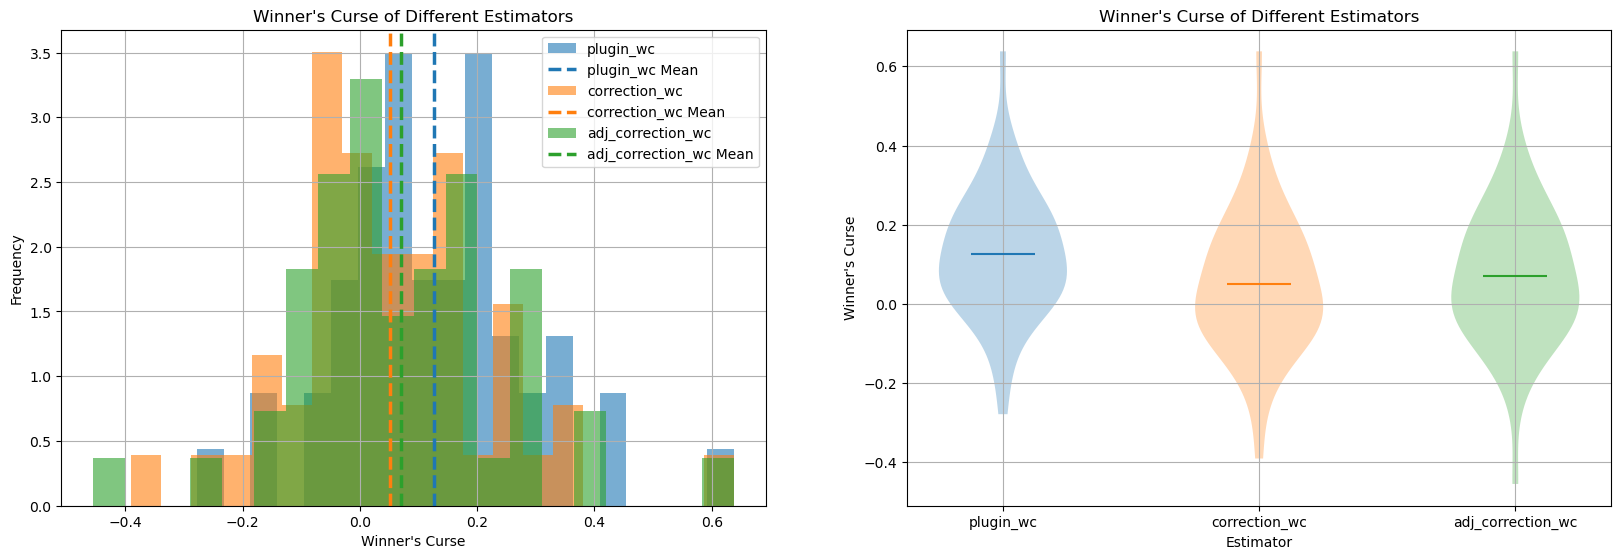

In [ ]:
plot_winners_curse_hist(
    'results/wc_grid11.csv', 
    estimators=list(estimators_dict.keys()),  
    sample_size=100, noise_std=1.0
)

## Test 2

In [156]:
# parameters
dgp_params = {
    'te_list': [1.0, 1.1],  # treatment effects for each group
    'group_func': lambda x: 0 if x < 0 else 1,  # group function
    'noise_std': 10.0,  # noise standard deviation
    'train_size': 100  # size of training set
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    }  # adjusted bootstrap correction estimator
}

In [158]:
grid_results = grid_experiment(
    sample_sizes=[100, 500, 1000, 1500, 2000, 3000, 4000, 5000], 
    num_bootstraps=[10000],
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/wc_grid2.csv',
    num_repeats=100, verbose=True
)

Sample size: 100, Num bootstrap: 10000, Time taken: 344.83 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 400.22 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 451.19 seconds
Sample size: 1500, Num bootstrap: 10000, Time taken: 486.44 seconds
Sample size: 2000, Num bootstrap: 10000, Time taken: 493.28 seconds
Sample size: 2500, Num bootstrap: 10000, Time taken: 560.76 seconds
Sample size: 5000, Num bootstrap: 10000, Time taken: 978.87 seconds


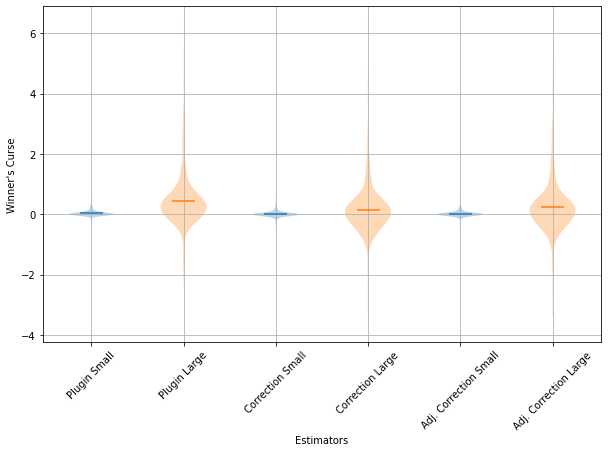

In [220]:
sm_std_results = pd.read_csv('results/wc_grid1.csv')
lg_std_results = pd.read_csv('results/wc_grid2.csv')

num_bootstrap = 10000

sm_std_results = sm_std_results[sm_std_results['num_bootstrap'] == num_bootstrap]
lg_std_results = lg_std_results[lg_std_results['num_bootstrap'] == num_bootstrap]

comp_df = pd.DataFrame({
    'sample_size': sm_std_results['sample_size'].values,
    'sm_std_plugin_wc': sm_std_results[['plugin']].sub(sm_std_results['act_plugin'], axis=0).values.flatten(), 
    'sm_std_corr_wc': sm_std_results[['corr']].sub(sm_std_results['act_plugin'], axis=0).values.flatten(),
    'sm_std_adj_corr_wc': sm_std_results[['adj_corr']].sub(sm_std_results['act_plugin'], axis=0).values.flatten(),
    'lg_std_plugin_wc': lg_std_results[['plugin']].sub(lg_std_results['act_plugin'], axis=0).values.flatten(),
    'lg_std_corr_wc': lg_std_results[['corr']].sub(lg_std_results['act_plugin'], axis=0).values.flatten(),
    'lg_std_adj_corr_wc': lg_std_results[['adj_corr']].sub(lg_std_results['act_plugin'], axis=0).values.flatten(),
})

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.violinplot(comp_df[['sm_std_plugin_wc', 'sm_std_corr_wc', 'sm_std_adj_corr_wc']].values, positions=[0, 2, 4], showmeans=True, showextrema=False)
ax.violinplot(comp_df[['lg_std_plugin_wc', 'lg_std_corr_wc', 'lg_std_adj_corr_wc']].values, positions=[1, 3, 5], showmeans=True, showextrema=False)

ax.set_xticks(range(6))
ax.set_xticklabels([
    'Plugin Small', 'Plugin Large', 
    'Correction Small', 'Correction Large', 
    'Adj. Correction Small', 'Adj. Correction Large'
], rotation=45)

ax.grid()
ax.set_ylabel("Winner's Curse")
ax.set_xlabel('Estimators')
plt.show()

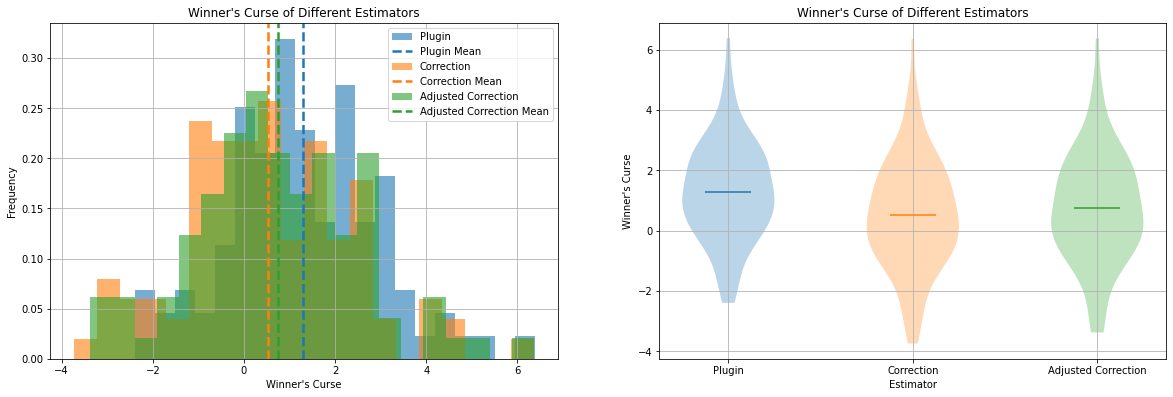

In [161]:
plot_winners_curse_hist('results/wc_grid2.csv', sample_size=100, num_bootstrap=10000)

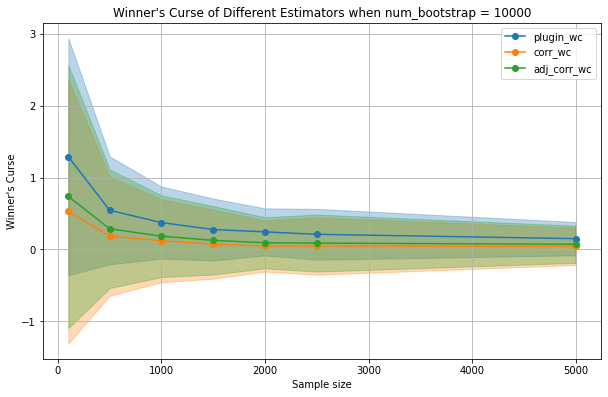

In [162]:
plot_winners_curse_2d('results/wc_grid2.csv', num_bootstrap=10000)

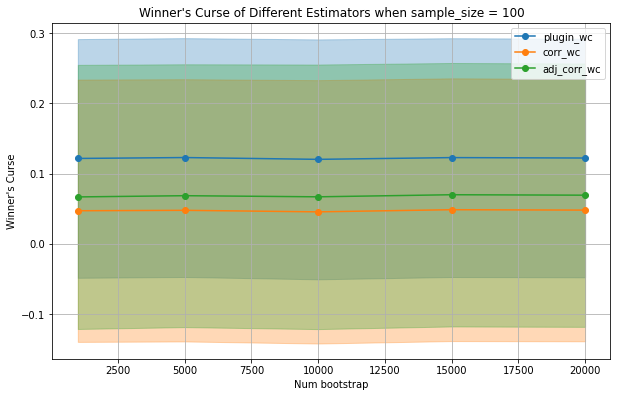

In [ ]:
plot_winners_curse_2d('results/grid2.csv', sample_size=100)

## Test 3

In [142]:
# parameters
def group_func(x):
    if x <= -1.5:
        return 0
    elif x <= 0:
        return 1
    elif x <= 1.5:
        return 2
    else:
        return 3
    
dgp_params = {
    'te_list': [0.9, 1.0, 1.1, 1.2],  # treatment effects for each group
    'group_func': group_func,  # group function
    'train_size': 100  # size of training set
}
targeting_params = {
    'size': 20,  # number of arriving customers
    'budget': 5,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    }  # adjusted bootstrap correction estimator
}

In [14]:
grid_results = grid_experiment(
    sample_sizes=[100, 500, 1000, 1500, 2000, 3000, 4000, 5000], 
    num_bootstraps=[5000, 10000, 15000, 20000],
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/wc_grid3.csv',
    num_repeats=50, verbose=True
)

Sample size: 100, Num bootstrap: 5000, Time taken: 169.08 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 338.05 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 518.35 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 686.76 seconds
Sample size: 500, Num bootstrap: 5000, Time taken: 175.74 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 361.12 seconds
Sample size: 500, Num bootstrap: 15000, Time taken: 541.05 seconds
Sample size: 500, Num bootstrap: 20000, Time taken: 717.27 seconds
Sample size: 1000, Num bootstrap: 5000, Time taken: 186.74 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 2289.31 seconds
Sample size: 1000, Num bootstrap: 15000, Time taken: 1538.88 seconds
Sample size: 1000, Num bootstrap: 20000, Time taken: 775.34 seconds
Sample size: 1500, Num bootstrap: 5000, Time taken: 197.85 seconds
Sample size: 1500, Num bootstrap: 10000, Time taken: 399.24 seconds
Sample size: 1500, Num bootstrap: 15000, Time taken: 607.1

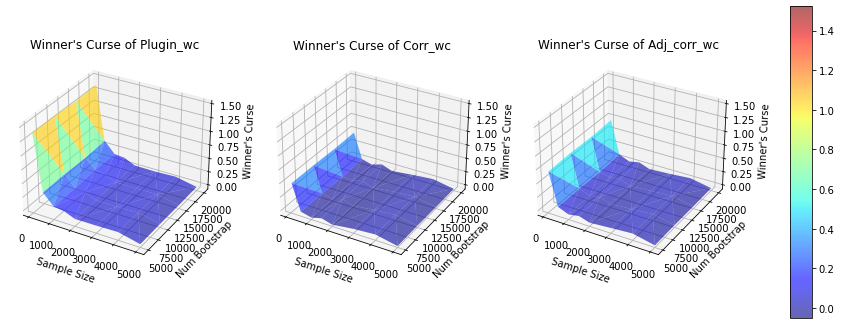

In [172]:
plot_winners_curse_3d('results/wc_grid3.csv')

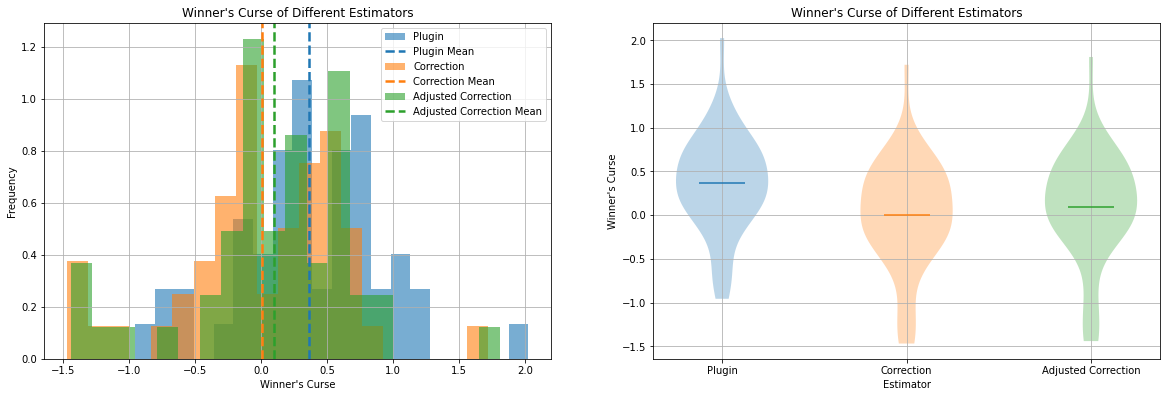

In [173]:
plot_winners_curse_hist('results/wc_grid3.csv', sample_size=500, num_bootstrap=5000)

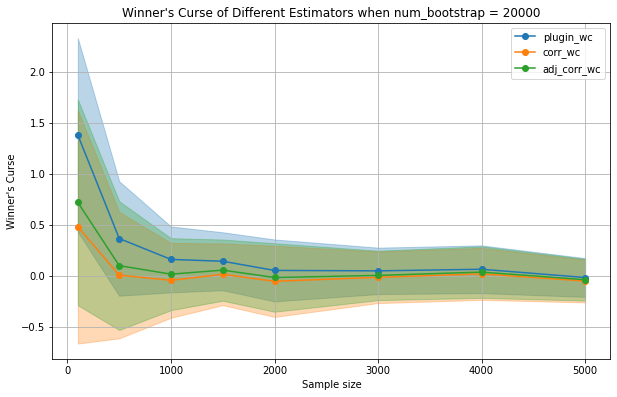

In [174]:
plot_winners_curse_2d('results/wc_grid3.csv', num_bootstrap=20000)

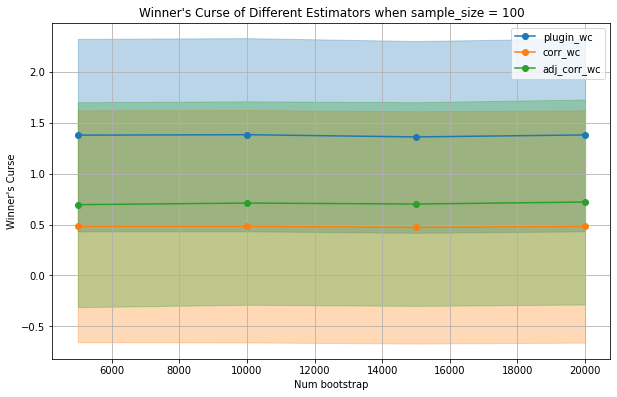

In [175]:
plot_winners_curse_2d('results/wc_grid3.csv', sample_size=100)

## Test 4

In [16]:
# parameters
def group_func(x):
    if x <= -1.5:
        return 0
    elif x <= 0:
        return 1
    elif x <= 1.5:
        return 2
    else:
        return 3
    
dgp_params = {
    'te_list': [0.9, 1.0, 1.1, 1.2],  # treatment effects for each group
    'group_func': group_func,  # group function
    'train_size': 100  # size of training set
}
targeting_params = {
    'size': 20,  # number of arriving customers
    'budget': 5,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    }  # adjusted bootstrap correction estimator
}

In [17]:
grid_results = grid_experiment(
    sample_sizes=[100], 
    num_bootstraps=[100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000],
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/wc_grid4.csv',
    num_repeats=50, verbose=True
)

Sample size: 100, Num bootstrap: 100, Time taken: 3.51 seconds
Sample size: 100, Num bootstrap: 500, Time taken: 17.30 seconds
Sample size: 100, Num bootstrap: 1000, Time taken: 34.30 seconds
Sample size: 100, Num bootstrap: 2000, Time taken: 68.69 seconds
Sample size: 100, Num bootstrap: 3000, Time taken: 103.04 seconds
Sample size: 100, Num bootstrap: 4000, Time taken: 137.92 seconds
Sample size: 100, Num bootstrap: 5000, Time taken: 175.75 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 352.42 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 529.00 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 22275.20 seconds


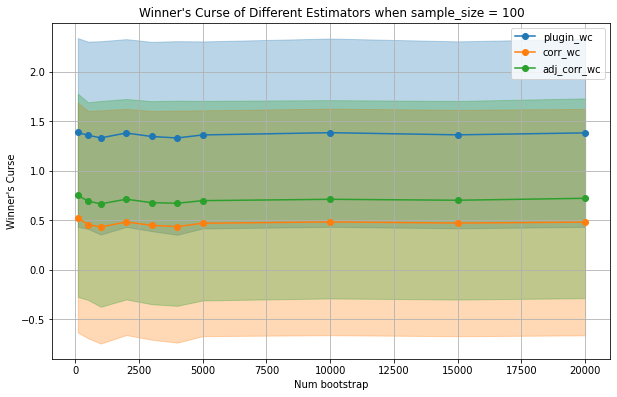

In [19]:
plot_winners_curse_2d('results/wc_grid4.csv', sample_size=100)